In [50]:
from google.colab import files
import io
import seaborn as sns # Necessário para usar sns.kdeplot
import pandas as pd
import statistics
import matplotlib.pyplot as plt # lib para gráficos
uploaded = files.upload()#NÃO FAZER O UPLOAD DO ARQUIVO MAIS DE UMA VEZ! Veja o slide

Saving letterboxd_movies_dataset.csv to letterboxd_movies_dataset.csv


Abrindo o CSV

In [51]:
df = pd.read_csv(
    io.BytesIO(uploaded['letterboxd_movies_dataset.csv']), comment="#"
  )
df.head()

,title,year,decade,decade_category,movie_era,age_years,age_category,runtime,runtime_category,runtime_percentile,...,language,is_english,title_length,title_complexity,word_count,title_runtime_ratio,runtime_efficiency,production_scale,is_recent,is_classic
0,Parasite,2019.0,2010.0,2010s,Contemporary,6.0,Recent,133.0,Long,P90,...,Korean,False,8.0,Short,1.0,0.060150,Balanced,Independent,False,False
1,Barbie,2023.0,2020.0,2020s,Contemporary,2.0,Brand_New,114.0,Standard,P80,...,English,True,6.0,Short,1.0,0.052632,Balanced,Independent,True,False
2,Interstellar,2014.0,2010.0,2010s,Contemporary,11.0,Recent,169.0,Long,P100,...,English,True,12.0,Medium,1.0,0.071006,Balanced,Commercial,False,False
3,Fight Club,1999.0,1990.0,1990s,Modern,26.0,Modern,139.0,Long,P100,...,English,True,10.0,Short,2.0,0.071942,Balanced,Commercial,False,False
4,La La Land,2016.0,2010.0,2010s,Contemporary,9.0,Recent,129.0,Long,P90,...,English,True,10.0,Short,3.0,0.077519,Balanced,Commercial,False,False


PANDAS

In [52]:
# selecionar apenas colunas (Features) relevantes pro trabalho
df = df[['title','year','decade','runtime','language','is_english', 'title_length', 'word_count']]
df.head()

,title,year,decade,runtime,language,is_english,title_length,word_count
0,Parasite,2019.0,2010.0,133.0,Korean,False,8.0,1.0
1,Barbie,2023.0,2020.0,114.0,English,True,6.0,1.0
2,Interstellar,2014.0,2010.0,169.0,English,True,12.0,1.0
3,Fight Club,1999.0,1990.0,139.0,English,True,10.0,2.0
4,La La Land,2016.0,2010.0,129.0,English,True,10.0,3.0


In [53]:
df[['title','year','decade','runtime','language','is_english', 'title_length', 'word_count']]

,title,year,decade,runtime,language,is_english,title_length,word_count
0,Parasite,2019.0,2010.0,133.0,Korean,False,8.0,1.0
1,Barbie,2023.0,2020.0,114.0,English,True,6.0,1.0
2,Interstellar,2014.0,2010.0,169.0,English,True,12.0,1.0
3,Fight Club,1999.0,1990.0,139.0,English,True,10.0,2.0
4,La La Land,2016.0,2010.0,129.0,English,True,10.0,3.0
...,...,...,...,...,...,...,...,...
16239,Vendhu Thanindhathu Kaadu,2022.0,2020.0,172.0,Tamil,False,25.0,3.0
16240,The Heart Is a Lonely Hunter,1968.0,1960.0,123.0,English,True,28.0,6.0
16241,The Shipping News,2001.0,2000.0,111.0,English,True,17.0,3.0
16242,"Police, Adjective",2009.0,2000.0,115.0,Romanian,False,17.0,2.0


Transformando o Pandas em dicionario de dicionarios

In [54]:
data_dict = df.reset_index().set_index('index').to_dict(orient='index')

In [55]:
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_limpo = df.dropna(subset=['runtime'])

lista_runtime = df_limpo['runtime'].tolist()

usable_runtime = lista_runtime[:10]

print("Os 10 primeiros valores válidos da coluna 'runtime' (em minutos):")
usable_runtime

Os 10 primeiros valores válidos da coluna 'runtime' (em minutos):


[133.0, 114.0, 169.0, 139.0, 129.0, 140.0, 107.0, 181.0, 154.0, 103.0]

In [56]:
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
# Cria um DataFrame limpo apenas com filmes que têm um runtime válido
df_runtime_limpo = df.dropna(subset=['runtime']).copy()


# --- 2. Implementação da Lógica de Classificação ---

# Garante que há dados para trabalhar
if not df_runtime_limpo.empty:

    # 1. Calcula a média (meio) de todos os runtimes válidos
    meio = df_runtime_limpo['runtime'].mean()

    # Inicializa o dicionário de contagem (análogo ao seu 'sp_def_lvl')
    runtime_lvl = {
        'Curto': 0,
        'Longo': 0
    }

    print(f"Total de filmes válidos para análise: {len(df_runtime_limpo)}")
    print(f"Média do Runtime de TODOS os filmes: {meio:.2f} minutos")
    print("-" * 50)

    # 2. Itera sobre a coluna de runtime do DataFrame limpo
    for tempo_duracao in df_runtime_limpo['runtime']:
        # Classificação: 'Curto' se menor que a média, 'Longo' se maior ou igual
        if tempo_duracao < meio:
            runtime_lvl['Curto'] += 1
        else:
            runtime_lvl['Longo'] += 1

    # --- 3. Resultado Final (Análogo a 'sp_def_lvl') ---
    print("Contagem Final (Classificação pelo Runtime):")
    runtime_lvl
else:
    print("ERRO: A coluna 'runtime' não possui dados válidos para o cálculo.")
    runtime_lvl = {'Curto': 0, 'Longo': 0}

runtime_lvl

Total de filmes válidos para análise: 16204
Média do Runtime de TODOS os filmes: 108.46 minutos
--------------------------------------------------
Contagem Final (Classificação pelo Runtime):


{'Curto': 10156, 'Longo': 6048}

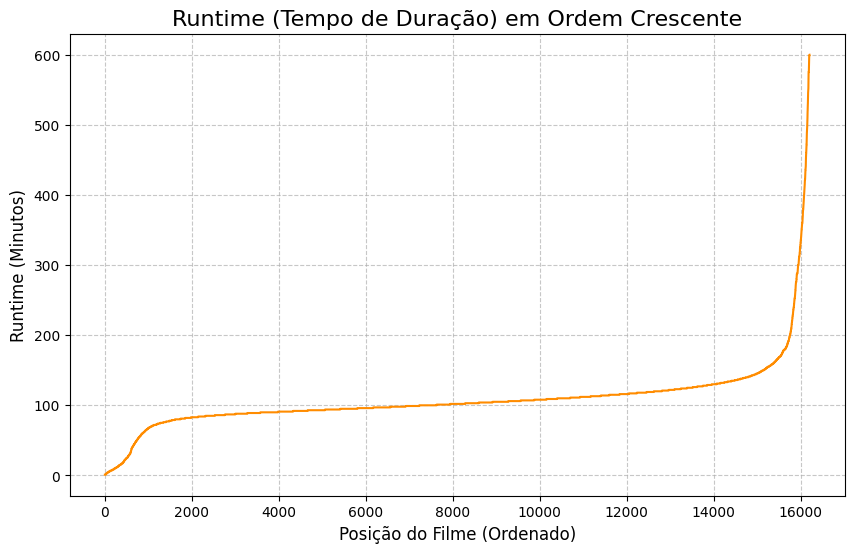

In [57]:
# 1. Garante que a coluna 'runtime' é numérica e remove NaNs (Limpeza Robusta)
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_runtime_limpo = df.dropna(subset=['runtime'])

# 2. Extrai a lista de todos os runtimes válidos
lista_runtime_completa = df_runtime_limpo['runtime'].tolist()

# 3. Ordena a lista (como no seu código original 'sorted(usable)')
runtime_ordenado = sorted(lista_runtime_completa)

# --- 2. Geração do Gráfico de Linha (Modelo Solicitado) ---

# Define o tamanho da figura
plt.figure(figsize=(10, 6))

# Plota o gráfico de linha. Usamos 'runtime_ordenado' no eixo Y
# e os índices (posições) dos filmes no eixo X.
plt.plot(
    runtime_ordenado,
    # Removendo o 'marker' e 'linestyle' para um visual mais limpo com muitos dados
    # Se quiser de volta, descomente as linhas abaixo:
    # marker='o',
    # linestyle='-',
    color='darkorange' # Cor alterada para dar destaque
)

plt.title("Runtime (Tempo de Duração) em Ordem Crescente", fontsize=16)
plt.xlabel("Posição do Filme (Ordenado)", fontsize=12)
plt.ylabel("Runtime (Minutos)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

Dados usados (Comprimento dos 10 primeiros títulos): [8.0, 6.0, 12.0, 10.0, 10.0, 33.0, 8.0, 11.0, 12.0, 15.0]
--------------------------------------------------


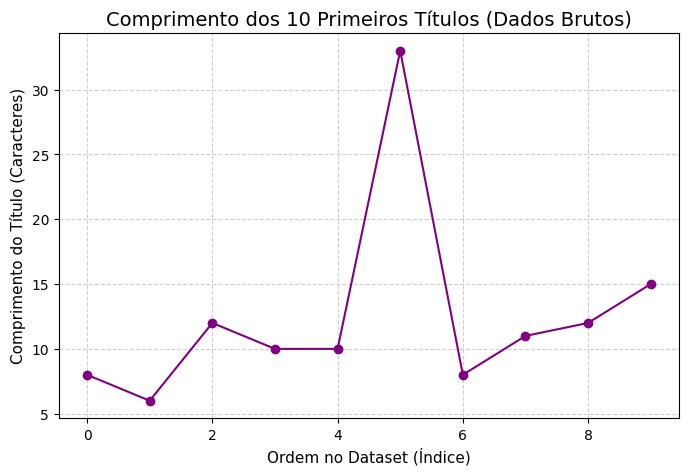

In [58]:
# 1. Garante que a coluna 'title_length' é numérica e remove NaNs
df['title_length'] = pd.to_numeric(df['title_length'], errors='coerce')
df_limpo = df.dropna(subset=['title_length'])

# 2. Extrai os 10 primeiros valores válidos (análogo ao seu 'usable')
lista_title_length = df_limpo['title_length'].tolist()
usable_title_length = lista_title_length[:10]

print(f"Dados usados (Comprimento dos 10 primeiros títulos): {usable_title_length}")
print("-" * 50)

# --- 2. Geração do Gráfico de Linha (Modelo Solicitado) ---

# Define o tamanho da figura
plt.figure(figsize=(8, 5))

# Plota os 10 valores na ordem em que aparecem no dataset
plt.plot(
    usable_title_length,
    marker='o',             # Exatamente como no seu exemplo
    linestyle='-',
    color='purple'          # Mudando a cor para diferenciar
)

plt.title("Comprimento dos 10 Primeiros Títulos (Dados Brutos)", fontsize=14)
plt.xlabel("Ordem no Dataset (Índice)", fontsize=11)
plt.ylabel("Comprimento do Título (Caracteres)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

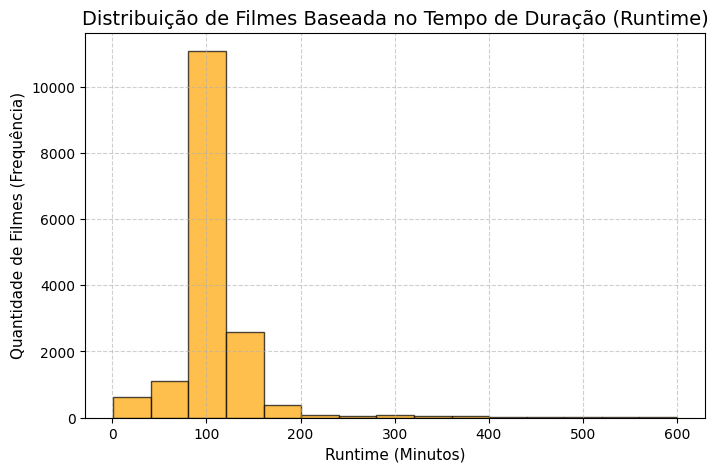

In [59]:
# 1. Garante que a coluna 'runtime' é numérica e remove NaNs (Limpeza Robusta)
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_runtime_limpo = df.dropna(subset=['runtime'])

# 2. Extrai a lista de todos os runtimes válidos
lista_runtime_completa = df_runtime_limpo['runtime'].tolist()

# --- 2. Geração do Histograma (Modelo Solicitado) ---

# Define o tamanho da figura
plt.figure(figsize=(8, 5))

# Plota o Histograma
plt.hist(
    lista_runtime_completa,
    bins=15,                 # Aumentei para 15 bins para melhor visualização, mas pode usar 8 se preferir
    color="orange",
    edgecolor="black",
    alpha=0.7
)

# Títulos e rótulos adaptados para o Runtime
plt.title("Distribuição de Filmes Baseada no Tempo de Duração (Runtime)", fontsize=14)
plt.xlabel("Runtime (Minutos)", fontsize=11)
plt.ylabel("Quantidade de Filmes (Frequência)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

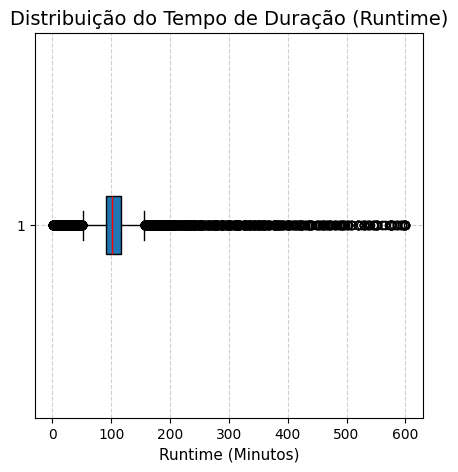

In [60]:
# 1. Garante que a coluna 'runtime' é numérica e remove NaNs (Limpeza Robusta)
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_runtime_limpo = df.dropna(subset=['runtime'])

# 2. Extrai a lista de todos os runtimes válidos
lista_runtime_completa = df_runtime_limpo['runtime'].tolist()

# --- 2. Geração do Box Plot (Modelo Solicitado) ---

# Define o tamanho da figura (mantendo o 5x5 do seu exemplo)
plt.figure(figsize=(5, 5))

# Plota o Box Plot
plt.boxplot(
    lista_runtime_completa,
    vert=False, # Define a orientação horizontal para melhor leitura
    patch_artist=True, # Preenche as caixas com cor
    boxprops=dict(facecolor='#1f77b4', color='black'), # Cor da caixa
    medianprops=dict(color='red') # Cor da linha da mediana
)

# Títulos e rótulos adaptados para o Runtime
plt.title("Distribuição do Tempo de Duração (Runtime)", fontsize=14)
plt.xlabel("Runtime (Minutos)", fontsize=11)
# O Box Plot horizontal não precisa de um rótulo no eixo Y (já que é uma variável)
# plt.ylabel("Filmes")

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

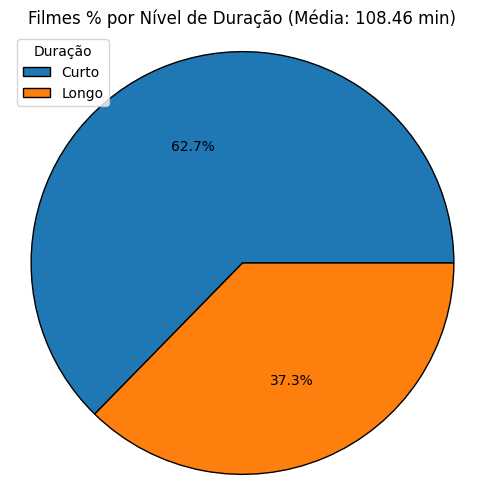

In [61]:
# 1. Garante que a coluna 'runtime' é numérica e remove NaNs
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_runtime_limpo = df.dropna(subset=['runtime']).copy()

# Garante que há dados para trabalhar
if not df_runtime_limpo.empty:

    # 2. Calcula a média (meio) de todos os runtimes válidos
    meio = df_runtime_limpo['runtime'].mean()

    # 3. Classifica e Conta (Gerando os valores para o gráfico)

    runtime_lvl = {
        'Curto': 0, # Abaixo da Média
        'Longo': 0  # Acima ou Igual à Média
    }

    # Itera para fazer a contagem
    for tempo_duracao in df_runtime_limpo['runtime']:
        if tempo_duracao < meio:
            runtime_lvl['Curto'] += 1
        else:
            runtime_lvl['Longo'] += 1

    # --- 2. Geração do Gráfico de Pizza (Modelo Solicitado) ---

    # Define o tamanho da figura (6x6 do seu exemplo)
    plt.figure(figsize=(6, 6))

    # Plota o gráfico de pizza
    plt.pie(
        runtime_lvl.values(), # Aqui passamos a qtde por cada categoria
        autopct='%1.1f%%',     # Apresenta valor percentual
        wedgeprops={'edgecolor': 'black'} # Adiciona borda preta para melhor separação
    )

    # Adiciona a legenda e o título
    plt.legend(
        runtime_lvl.keys(),
        title="Duração",
        loc="upper left"
    )
    plt.title(f"Filmes % por Nível de Duração (Média: {meio:.2f} min)", fontsize=12)
    plt.axis("equal") # Garante que o círculo fique redondo
    plt.show()


else:
    print("ERRO: O DataFrame de runtime está vazio. Não é possível gerar o gráfico.")

Média do Runtime: 108.46 minutos
Contagens: {'Curto': 10156, 'Longo': 6048}
--------------------------------------------------


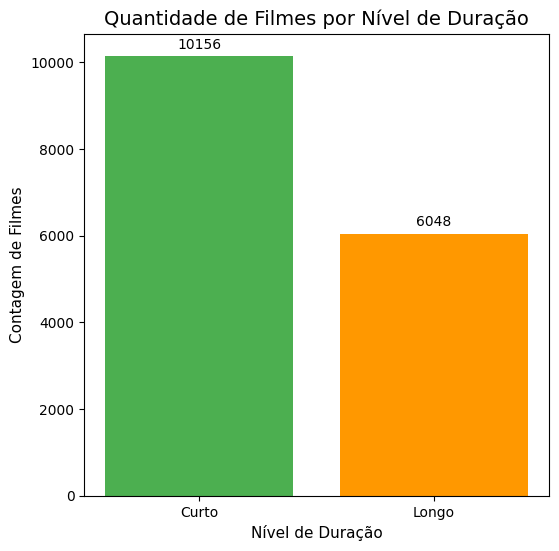

In [62]:
# 1. Garante que a coluna 'runtime' é numérica e remove NaNs
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_runtime_limpo = df.dropna(subset=['runtime']).copy()

# Garante que há dados para trabalhar
if not df_runtime_limpo.empty:

    # 2. Calcula a média (meio) de todos os runtimes válidos
    meio = df_runtime_limpo['runtime'].mean()

    # 3. Classifica e Conta (Gerando os valores para o gráfico)
    runtime_lvl = {
        'Curto': 0, # Abaixo da Média
        'Longo': 0  # Acima ou Igual à Média
    }

    # Itera para fazer a contagem
    for tempo_duracao in df_runtime_limpo['runtime']:
        if tempo_duracao < meio:
            runtime_lvl['Curto'] += 1
        else:
            runtime_lvl['Longo'] += 1

    print(f"Média do Runtime: {meio:.2f} minutos")
    print(f"Contagens: {runtime_lvl}")
    print("-" * 50)

    # --- 2. Geração do Gráfico de Barras (Modelo Solicitado) ---

    # Define o tamanho da figura (6x6 do seu exemplo)
    plt.figure(figsize=(6, 6))

    # Plota o gráfico de barras
    plt.bar(
        runtime_lvl.keys(), # Chaves ('Curto', 'Longo') no eixo X
        runtime_lvl.values(), # Valores (Contagens) no eixo Y
        color=['#4CAF50', '#FF9800'] # Cores personalizadas
    )

    # Títulos e rótulos
    plt.title("Quantidade de Filmes por Nível de Duração", fontsize=14)
    plt.xlabel("Nível de Duração", fontsize=11)
    plt.ylabel("Contagem de Filmes", fontsize=11)

    # Adiciona os valores no topo das barras
    for i, count in enumerate(runtime_lvl.values()):
        plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=10)

    plt.show()


else:
    print("ERRO: O DataFrame de runtime está vazio. Não é possível gerar o gráfico.")

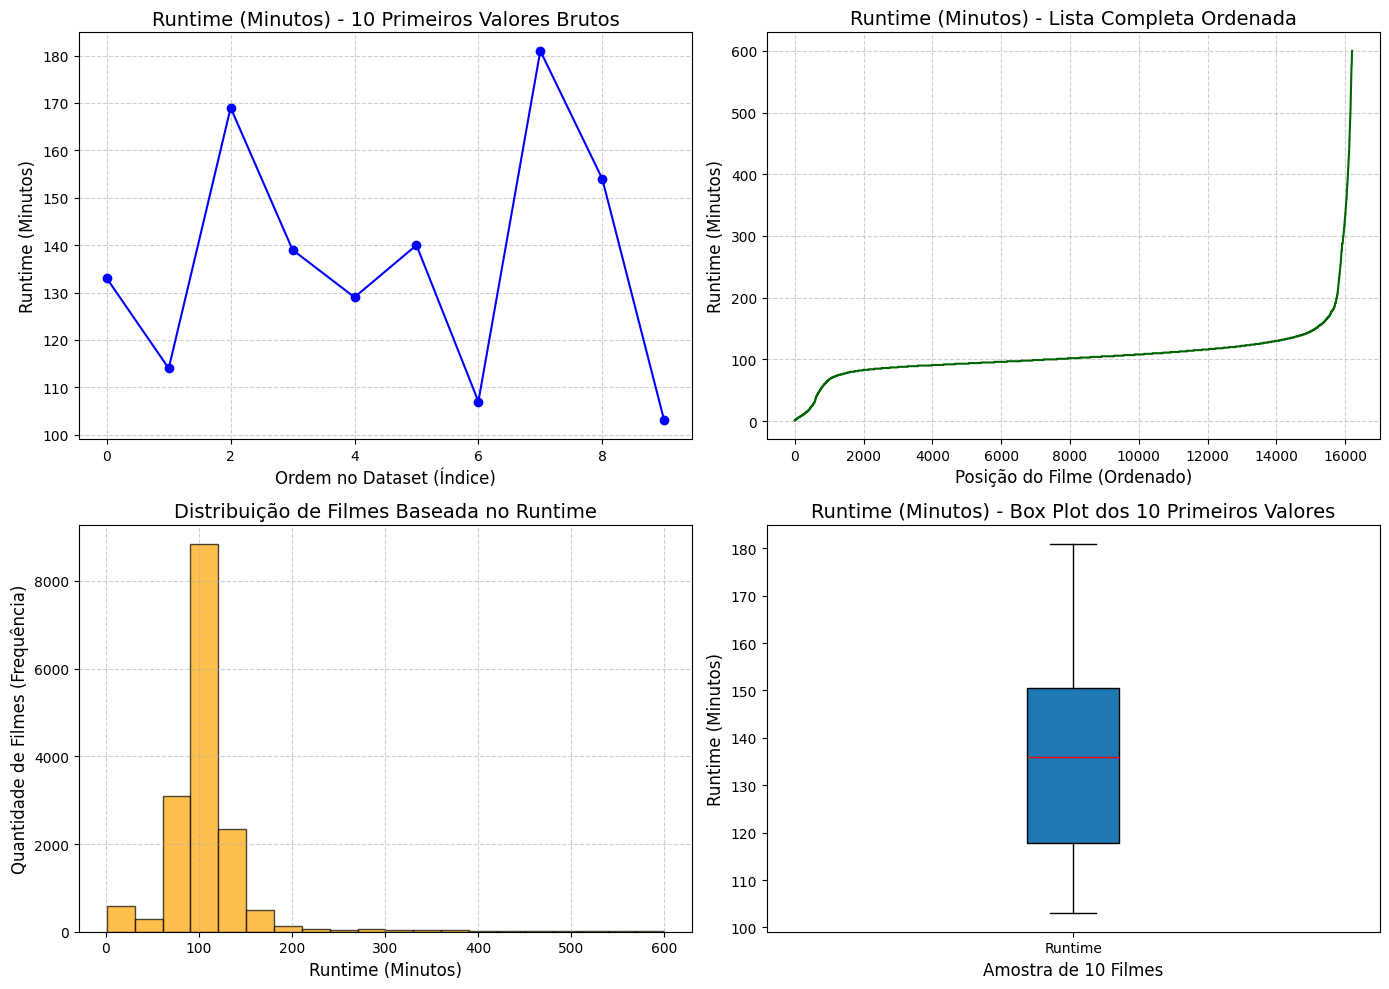

In [63]:
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_runtime_limpo = df.dropna(subset=['runtime'])

# 2. Extrai as listas de dados
lista_runtime_completa = df_runtime_limpo['runtime'].tolist()
# Usamos os 10 primeiros valores válidos para o 'usable' (análogo)
usable_runtime = lista_runtime_completa[:10]

# --- 2. Geração da Figura Subplot 2x2 ---

fig, axs = plt.subplots(2, 2, figsize=(14,10))

# ----------------- PLOT 1: TOP LEFT (Linha, Dados Brutos - 10 valores) -----------------
# Análogo a: axs[0,0].plot(usable, ...)
axs[0,0].plot(usable_runtime, marker='o', linestyle='-', color='blue')
axs[0,0].set_title("Runtime (Minutos) - 10 Primeiros Valores Brutos", fontsize=14)
axs[0,0].set_ylabel("Runtime (Minutos)", fontsize=12)
axs[0,0].set_xlabel("Ordem no Dataset (Índice)", fontsize=12)
axs[0,0].grid(True, linestyle="--", alpha=0.6)

# ----------------- PLOT 2: TOP RIGHT (Linha, Lista Completa Ordenada) -----------------
# Análogo a: axs[0,1].plot(sorted(lista_sp_def), ...)
axs[0,1].plot(sorted(lista_runtime_completa), marker='', linestyle='-', color='darkgreen')
axs[0,1].set_title("Runtime (Minutos) - Lista Completa Ordenada", fontsize=14)
axs[0,1].set_ylabel("Runtime (Minutos)", fontsize=12)
axs[0,1].set_xlabel("Posição do Filme (Ordenado)", fontsize=12)
axs[0,1].grid(True, linestyle="--", alpha=0.6)

# ----------------- PLOT 3: BOTTOM LEFT (Histograma - Lista Completa) -----------------
# Análogo a: axs[1,0].hist(lista_sp_def, ...)
axs[1,0].hist(
    lista_runtime_completa,
    bins=20, # Usando 20 bins para dataset grande (melhor visualização)
    color="orange",
    edgecolor="black",
    alpha=0.7
)
axs[1,0].set_title("Distribuição de Filmes Baseada no Runtime", fontsize=14)
axs[1,0].set_xlabel("Runtime (Minutos)", fontsize=12)
axs[1,0].set_ylabel("Quantidade de Filmes (Frequência)", fontsize=12)
axs[1,0].grid(True, linestyle="--", alpha=0.6)

# ----------------- PLOT 4: BOTTOM RIGHT (Boxplot - 10 Valores Brutos) -----------------
# Análogo a: axs[1,1].boxplot(usable, ...)
axs[1,1].boxplot(
    usable_runtime,
    patch_artist=True,
    boxprops=dict(facecolor='#1f77b4', color='black'),
    medianprops=dict(color='red')
)
axs[1,1].set_title("Runtime (Minutos) - Box Plot dos 10 Primeiros Valores", fontsize=14)
axs[1,1].set_xlabel("Amostra de 10 Filmes", fontsize=12)
axs[1,1].set_xticklabels(['Runtime']) # Adiciona rótulo no eixo X para Box Plot
axs[1,1].set_ylabel("Runtime (Minutos)", fontsize=12)

# Ajusta espaçamento e mostra
plt.tight_layout()
plt.show()

Média do Runtime: 108.46 minutos
Contagens: {'Curto': 10156, 'Longo': 6048}
--------------------------------------------------


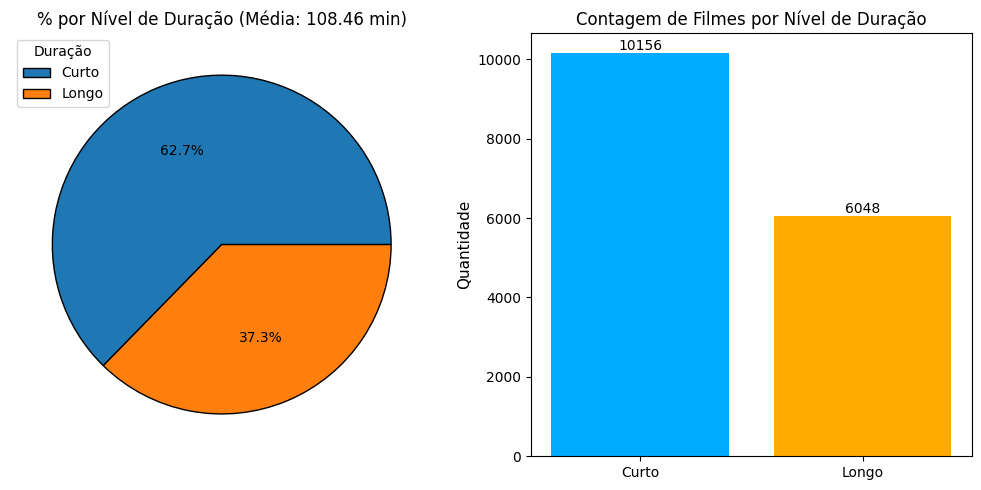

In [64]:
# 1. Garante que a coluna 'runtime' é numérica e remove NaNs
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_runtime_limpo = df.dropna(subset=['runtime']).copy()

# Garante que há dados para trabalhar
if not df_runtime_limpo.empty:

    # 2. Calcula a média (meio) de todos os runtimes válidos
    meio = df_runtime_limpo['runtime'].mean()

    # 3. Classifica e Conta (Gerando os valores para o gráfico)
    runtime_lvl = {
        'Curto': 0, # Abaixo da Média
        'Longo': 0  # Acima ou Igual à Média
    }

    # Itera para fazer a contagem
    for tempo_duracao in df_runtime_limpo['runtime']:
        if tempo_duracao < meio:
            runtime_lvl['Curto'] += 1
        else:
            runtime_lvl['Longo'] += 1

    print(f"Média do Runtime: {meio:.2f} minutos")
    print(f"Contagens: {runtime_lvl}")
    print("-" * 50)

    # --- 2. Geração do Subplot 1x2 (Modelo Solicitado) ---

    fig, axs = plt.subplots(1, 2, figsize=(10,5))

    # --- Gráfico de Pizza (axs[0]) ---
    axs[0].pie(
        runtime_lvl.values(), # Aqui passamos a qtde por cada categoria
        autopct='%1.1f%%',     # Apresenta valor percentual
        wedgeprops={'edgecolor': 'black'}
    )
    axs[0].set_title(f"% por Nível de Duração (Média: {meio:.2f} min)", fontsize=12)
    axs[0].legend(
        runtime_lvl.keys(),
        title="Duração",
        loc="upper left"
    )

    # --- Gráfico de Barras (axs[1]) ---
    axs[1].bar(
        runtime_lvl.keys(),
        runtime_lvl.values(),
        color=['#00aaff', '#ffaa00'] # Cores adaptadas
    )
    axs[1].set_title("Contagem de Filmes por Nível de Duração", fontsize=12)
    axs[1].set_ylabel("Quantidade", fontsize=11)

    # Adiciona os valores no topo das barras
    for i, count in enumerate(runtime_lvl.values()):
        axs[1].text(i, count, str(count), ha='center', va='bottom', fontsize=10)

    # Ajusta espaçamento
    plt.tight_layout()
    plt.show()

else:
    print("ERRO: O DataFrame de runtime está vazio. Não é possível gerar o gráfico.")

Dados usados (10 Primeiros Runtimes): [133.0, 114.0, 169.0, 139.0, 129.0, 140.0, 107.0, 181.0, 154.0, 103.0]
--------------------------------------------------


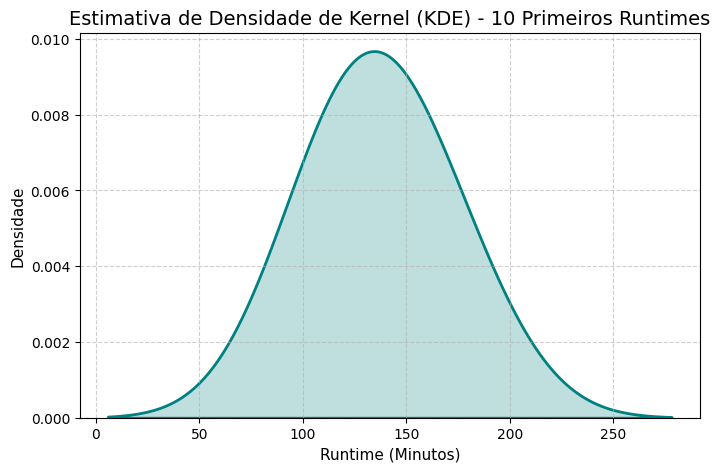

In [65]:
# 1. Garante que a coluna 'runtime' é numérica e remove NaNs
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df_limpo = df.dropna(subset=['runtime'])

# 2. Extrai os 10 primeiros valores válidos (análogo ao seu 'usable')
lista_runtime = df_limpo['runtime'].tolist()
usable_runtime = lista_runtime[:10]

print(f"Dados usados (10 Primeiros Runtimes): {usable_runtime}")
print("-" * 50)

# --- 2. Geração do KDE Plot (Modelo Solicitado) ---

plt.figure(figsize=(8, 5))

sns.kdeplot(
    usable_runtime,
    fill=True,
    bw_adjust=2, # Suavização conforme solicitada
    color='teal', # Cor adaptada
    linewidth=2
)

plt.title("Estimativa de Densidade de Kernel (KDE) - 10 Primeiros Runtimes", fontsize=14)
plt.xlabel("Runtime (Minutos)", fontsize=11)
plt.ylabel("Densidade", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

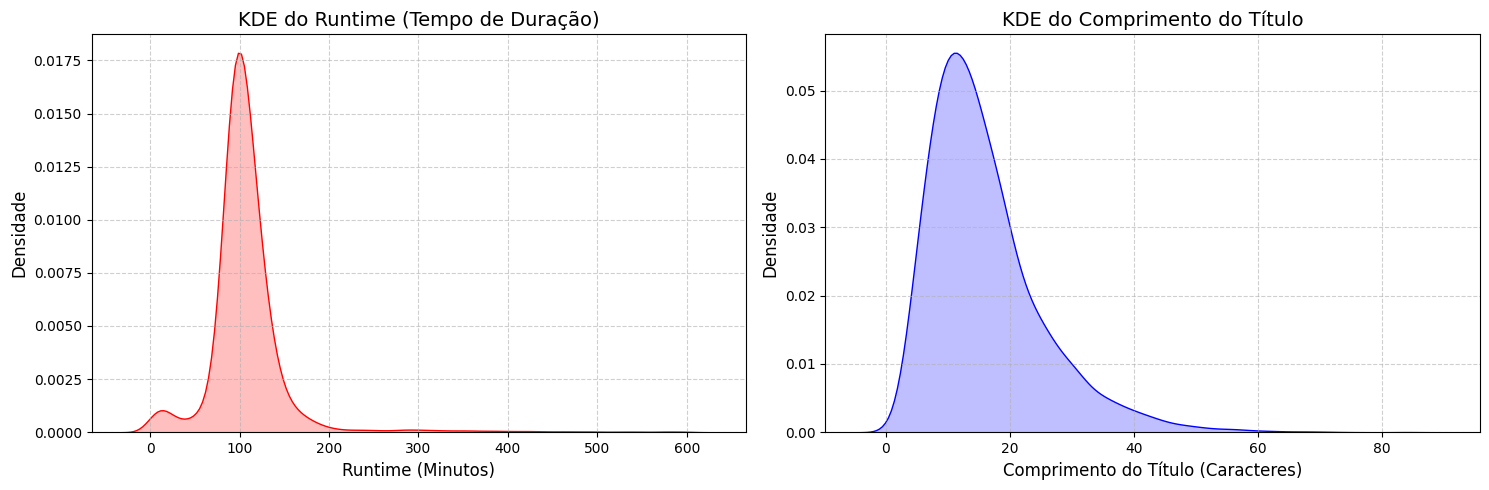

In [66]:
# 1. Limpeza Robusta: Garante que as colunas são numéricas e remove NaNs
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df['title_length'] = pd.to_numeric(df['title_length'], errors='coerce')

# Cria um DataFrame limpo com as colunas necessárias, removendo qualquer linha que
# contenha NaN em uma dessas duas colunas.
KDEdata_adapted = df[['runtime', 'title_length']].dropna()

# --- 2. Geração do Subplot 1x2 (Modelo Solicitado) ---

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# --- Gráfico 1: Runtime (Análogo a 'Special Attack') ---
sns.kdeplot(
    data=KDEdata_adapted,
    x='runtime',
    fill=True,
    ax=axes[0],
    color='red', # Cor adaptada
    bw_adjust=1.5 # Ajusta a suavização
)
axes[0].set_title('KDE do Runtime (Tempo de Duração)', fontsize=14)
axes[0].set_xlabel('Runtime (Minutos)', fontsize=12)
axes[0].set_ylabel('Densidade', fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.6)

# --- Gráfico 2: Title Length (Análogo a 'Special Defense') ---
sns.kdeplot(
    data=KDEdata_adapted,
    x='title_length',
    fill=True,
    ax=axes[1],
    color='blue', # Cor adaptada
    bw_adjust=1.5 # Ajusta a suavização
)
axes[1].set_title('KDE do Comprimento do Título', fontsize=14)
axes[1].set_xlabel('Comprimento do Título (Caracteres)', fontsize=12)
axes[1].set_ylabel('Densidade', fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)

# Ajusta espaçamento
plt.tight_layout()
plt.show()

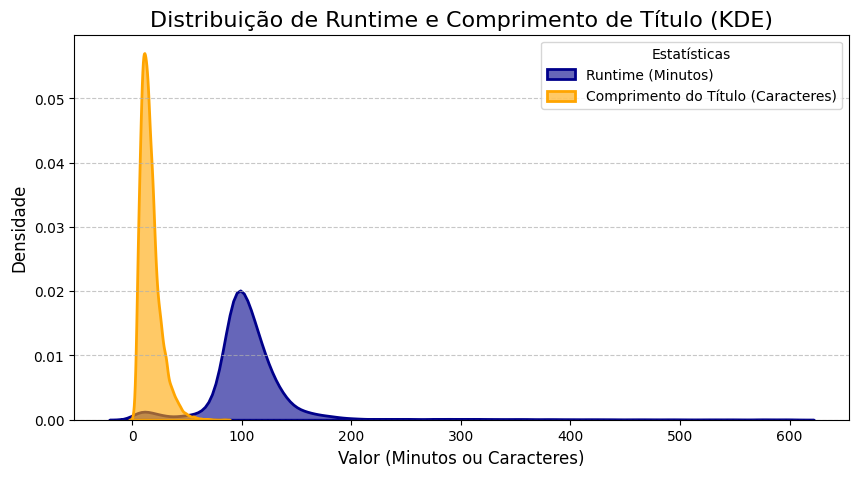

In [67]:
# 1. Limpeza Robusta: Garante que as colunas são numéricas e remove NaNs
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df['title_length'] = pd.to_numeric(df['title_length'], errors='coerce')

# Cria um DataFrame limpo com as colunas necessárias, removendo qualquer linha que
# contenha NaN em uma dessas duas colunas para garantir dados alinhados.
KDEdata_adapted = df[['runtime', 'title_length']].dropna()

# --- 2. Geração do KDE Plot Sobreposto (Modelo Solicitado) ---

plt.figure(figsize=(10, 5))

# --- KDE 1: Runtime ---
sns.kdeplot(
    data=KDEdata_adapted,
    x='runtime',
    fill=True,
    linewidth=2,
    color='darkblue',
    alpha=0.6,
    label='Runtime (Minutos)' # Adiciona label para a legenda
)

# --- KDE 2: Title Length ---
# Nota: É importante plotar as duas distribuições em escalas diferentes.
# Para fins de visualização, o 'title_length' é geralmente muito menor que o 'runtime'.
# Para a comparação ser visualmente útil, plotamos ambas no mesmo eixo X.
sns.kdeplot(
    data=KDEdata_adapted,
    x='title_length',
    fill=True,
    linewidth=2,
    color='orange', # Cor adaptada para amarelo/laranja
    alpha=0.6,
    label='Comprimento do Título (Caracteres)' # Adiciona label para a legenda
)

# Adiciona a legenda e o título
plt.legend(title="Estatísticas", loc="upper right")
plt.title('Distribuição de Runtime e Comprimento de Título (KDE)', fontsize=16)

# Rótulos (os rótulos do eixo X serão uma combinação das duas colunas)
plt.xlabel('Valor (Minutos ou Caracteres)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()